# Satellite Image-Based Wildlife Poaching Risk Prediction

## Project Overview
**Author:** Iago Graziano Gazzara - Arpit Ghai 
**Date:** 2025 
**Objective:** Develop machine learning models to predict wildlife poaching risk from satellite images

---

## Abstract
This project aims to predict poaching risk levels (LOW, MEDIUM, HIGH) using satellite imagery. By analyzing satellite images of geographic grids, we can identify patterns and features that correlate with poaching activity, enabling proactive conservation efforts.


## 1. Problem Statement

Wildlife poaching poses a severe threat to biodiversity and conservation efforts worldwide. Traditional monitoring methods are resource-intensive and often reactive rather than preventive.

**Problem:** Develop an automated system that can analyze satellite images of geographic regions and predict the risk level of poaching activity.

**Approach:**
- Use satellite imagery to identify environmental patterns associated with poaching risk
- Classify images into three risk levels: LOW, MEDIUM, HIGH
- Enable early warning systems for conservation authorities

**Expected Impact:**
- Proactive identification of high-risk areas
- Optimized allocation of conservation resources
- Enhanced wildlife protection through predictive analytics
- Data-driven decision making for ranger deployment


In [71]:
# Import required libraries
import sys
import os
from pathlib import Path
import importlib

# Add project root to path
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


Using device: cpu
PyTorch version: 2.9.1+cpu


## 2. Dataset Overview

### 2.1 Load and Explore Data


In [72]:
# Load the dataset
df = pd.read_csv('data.csv')

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df[['poaching_risk', 'image_path']].head(10))

# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)
print(df.isnull().sum())

# Check data types
print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)


DATASET OVERVIEW

Dataset Shape: (5094, 15)

Columns: ['id', 'Grid_ID', 'Lat', 'Lon', 'centroid_x', 'centroid_y', 'NDVI', 'geometry', 'landcover', 'Water', 'dist_to_water', 'burned_area', 'elevation', 'poaching_risk', 'image_path']

First few rows:
  poaching_risk                            image_path
0        Medium  grid_patches_final_png\grid_2793.png
1          High  grid_patches_final_png\grid_2795.png
2        Medium  grid_patches_final_png\grid_2536.png
3        Medium  grid_patches_final_png\grid_2797.png
4        Medium  grid_patches_final_png\grid_2538.png
5        Medium  grid_patches_final_png\grid_2534.png
6        Medium  grid_patches_final_png\grid_2540.png
7        Medium  grid_patches_final_png\grid_2539.png
8        Medium  grid_patches_final_png\grid_2537.png
9        Medium  grid_patches_final_png\grid_2794.png

MISSING VALUES
id                  0
Grid_ID             0
Lat                 0
Lon                 0
centroid_x          0
centroid_y          0
NDVI     

TARGET VARIABLE DISTRIBUTION

Counts:
poaching_risk
Medium    4589
Low        307
High       198
Name: count, dtype: int64

Percentages:
poaching_risk
Medium    90.086376
Low        6.026698
High       3.886926
Name: proportion, dtype: float64


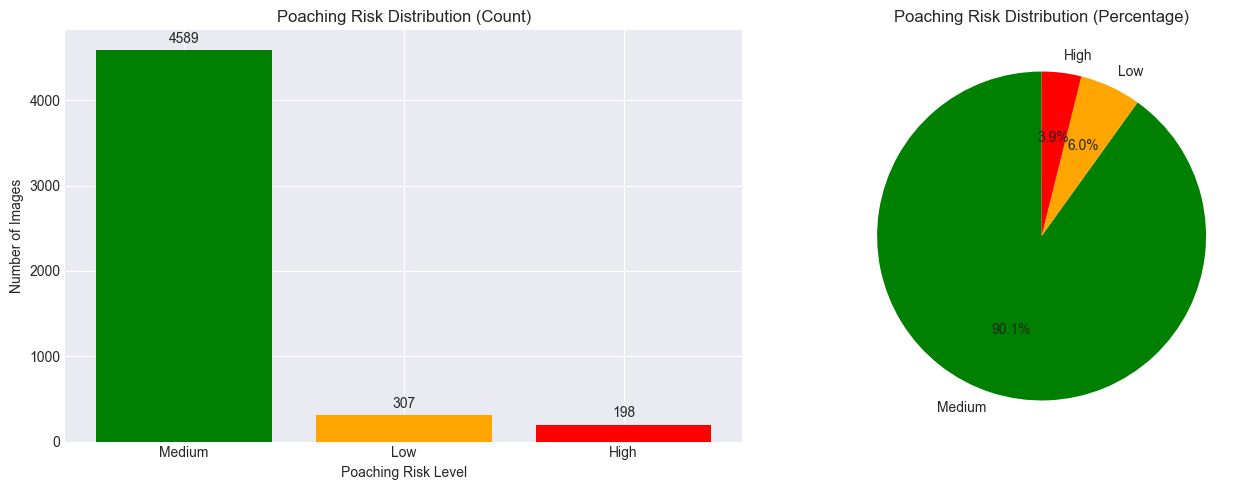


⚠️  Class Imbalance Detected!
   - Medium: 4589 (90.1%)
   - Low: 307 (6.0%)
   - High: 198 (3.9%)


In [73]:
# Analyze target variable distribution
print("=" * 80)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 80)

risk_counts = df['poaching_risk'].value_counts()
risk_percentages = df['poaching_risk'].value_counts(normalize=True) * 100

print("\nCounts:")
print(risk_counts)
print("\nPercentages:")
print(risk_percentages)

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(risk_counts.index, risk_counts.values, color=['green', 'orange', 'red'])
axes[0].set_xlabel('Poaching Risk Level')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Poaching Risk Distribution (Count)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', va='bottom')

# Pie chart
axes[1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
            colors=['green', 'orange', 'red'], startangle=90)
axes[1].set_title('Poaching Risk Distribution (Percentage)')

plt.tight_layout()
plt.show()

print(f"\n⚠️  Class Imbalance Detected!")
print(f"   - Medium: {risk_counts['Medium']} ({risk_percentages['Medium']:.1f}%)")
print(f"   - Low: {risk_counts['Low']} ({risk_percentages['Low']:.1f}%)")
print(f"   - High: {risk_counts['High']} ({risk_percentages['High']:.1f}%)")


### 2.2 Visualize Sample Images


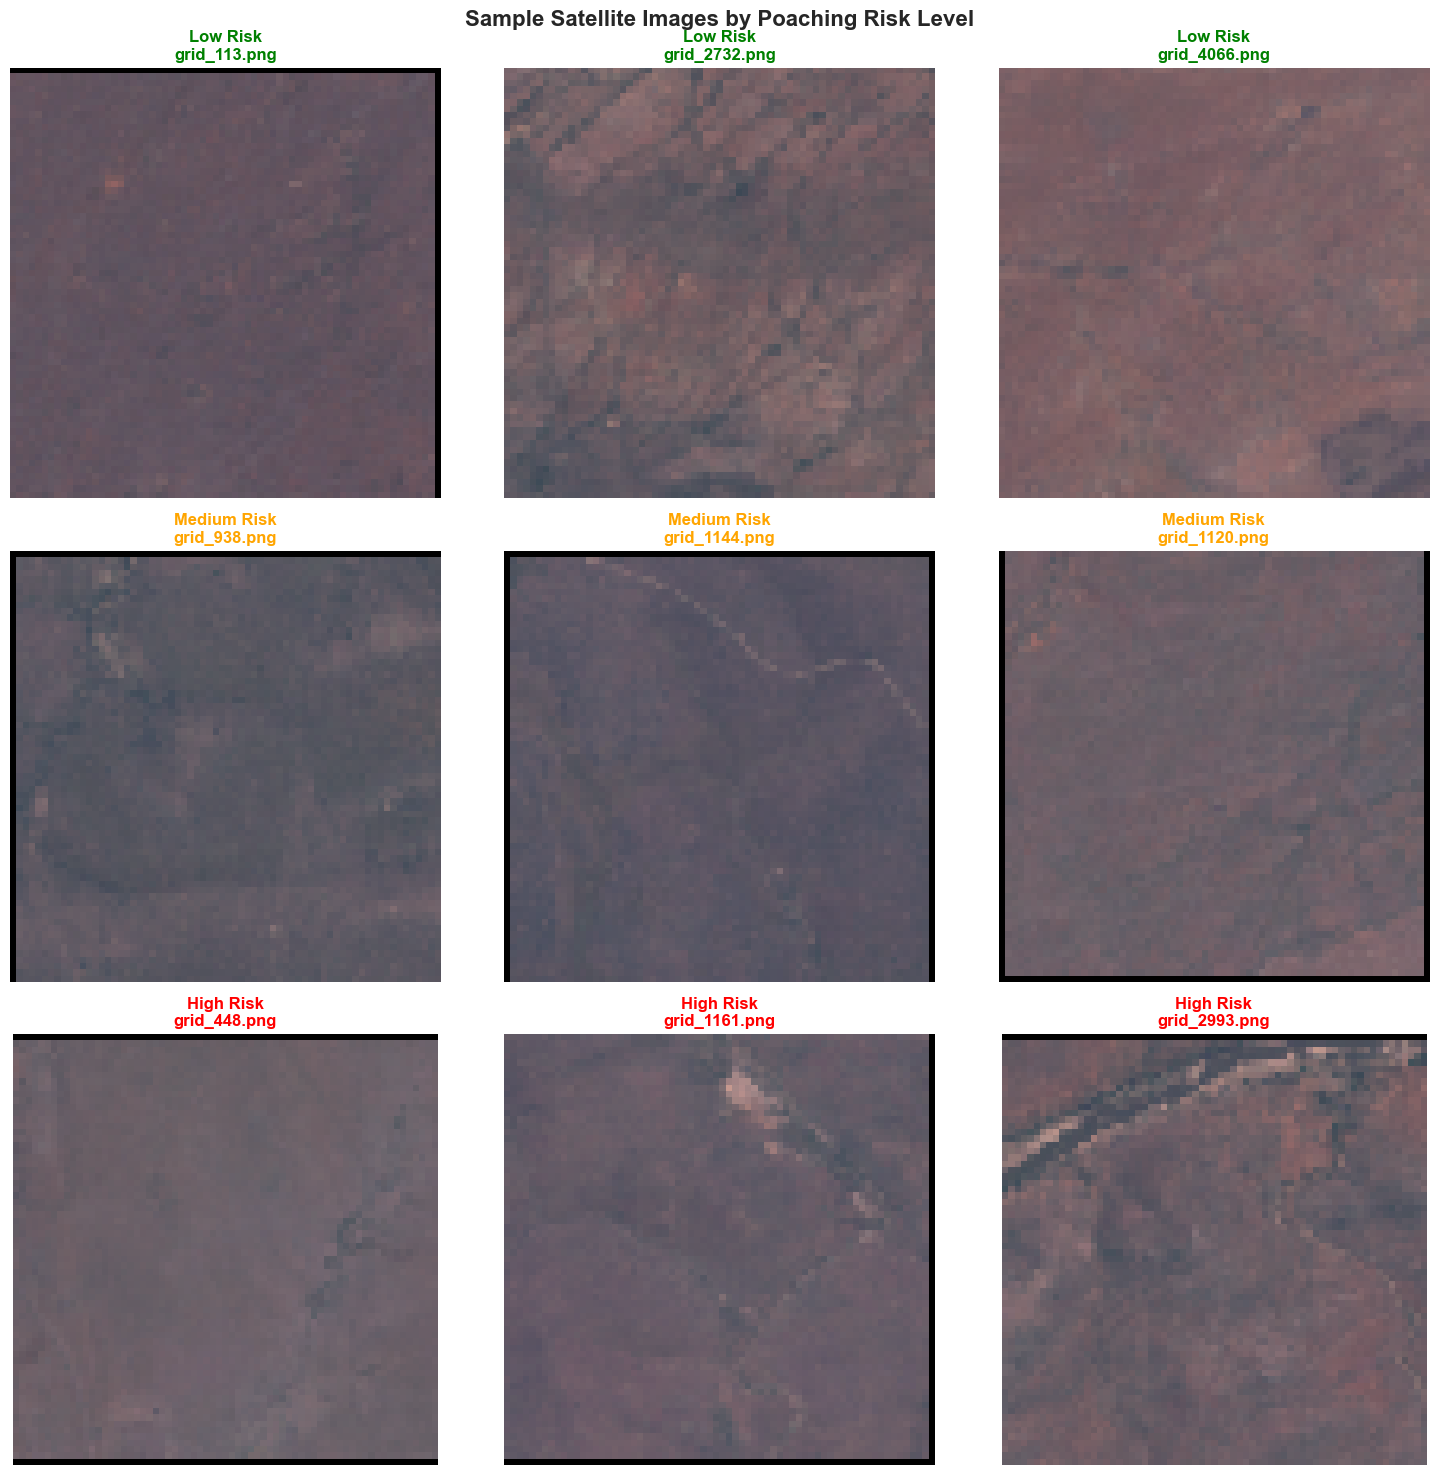

In [74]:
# Function to visualize sample images from each class
def visualize_samples(df, images_dir='grid_images', num_samples=3):
    """Visualize sample images from each risk category."""
    fig, axes = plt.subplots(3, num_samples, figsize=(15, 15))

    risk_levels = ['Low', 'Medium', 'High']
    colors = ['green', 'orange', 'red']

    for row, risk_level in enumerate(risk_levels):
        # Get samples for this risk level
        samples = df[df['poaching_risk'] == risk_level].sample(
            n=min(num_samples, len(df[df['poaching_risk'] == risk_level])),
            random_state=42
        )

        for col, idx in enumerate(samples.index):
            img_path = Path(images_dir) / samples.loc[idx, 'image_path'].split('\\')[-1]

            if img_path.exists():
                img = Image.open(img_path)
                axes[row, col].imshow(img)
                axes[row, col].set_title(f'{risk_level} Risk\n{img_path.name}',
                                         color=colors[row], fontweight='bold')
                axes[row, col].axis('off')
            else:
                axes[row, col].text(0.5, 0.5, f'Image not found:\n{img_path.name}',
                                   ha='center', va='center')
                axes[row, col].axis('off')

    plt.suptitle('Sample Satellite Images by Poaching Risk Level', fontsize=16, fontweight='bold')
    plt.tight_layout()
    return plt.gcf()

# Visualize samples
fig = visualize_samples(df, images_dir='grid_images', num_samples=3)
plt.show()


In [75]:
# Check image properties
print("=" * 80)
print("IMAGE PROPERTIES ANALYSIS")
print("=" * 80)

sample_images = []
for risk_level in ['Low', 'Medium', 'High']:
    sample = df[df['poaching_risk'] == risk_level].iloc[0]
    img_path = Path('grid_images') / sample['image_path'].split('\\')[-1]
    if img_path.exists():
        img = Image.open(img_path)
        sample_images.append({
            'risk': risk_level,
            'size': img.size,
            'mode': img.mode,
            'format': img.format
        })

img_props_df = pd.DataFrame(sample_images)
print("\nSample Image Properties:")
print(img_props_df)

# Check if all images exist
print("\n" + "=" * 80)
print("IMAGE FILE VALIDATION")
print("=" * 80)

missing_images = []
for idx, row in df.iterrows():
    img_path = Path('grid_images') / row['image_path'].split('\\')[-1]
    if not img_path.exists():
        missing_images.append(row['image_path'])

if missing_images:
    print(f"⚠️  Warning: {len(missing_images)} images not found")
    print(f"   First few missing: {missing_images[:5]}")
else:
    print("✓ All images found!")


IMAGE PROPERTIES ANALYSIS

Sample Image Properties:
     risk      size mode format
0     Low  (68, 68)  RGB    PNG
1  Medium   (4, 26)  RGB    PNG
2    High   (9, 53)  RGB    PNG

IMAGE FILE VALIDATION
✓ All images found!


### 2.3 Data Preprocessing

We'll create a custom dataset class and prepare data loaders with proper train/validation/test splits.


In [76]:
# Custom Dataset Class for Satellite Images
class SatellitePoachingDataset(Dataset):
    """Dataset class for satellite poaching risk images."""

    def __init__(self, dataframe, images_dir, transform=None):
        """
        Args:
            dataframe: DataFrame with 'image_path' and 'poaching_risk' columns
            images_dir: Directory containing images
            transform: Image transformations
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.transform = transform

        # Encode labels
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.dataframe['poaching_risk'])
        self.classes = self.label_encoder.classes_

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Get image path
        img_path_str = self.dataframe.loc[idx, 'image_path']
        img_filename = img_path_str.split('\\')[-1]  # Handle Windows path separator
        img_path = self.images_dir / img_filename

        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a black image as fallback
            image = Image.new('RGB', (224, 224), color='black')

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Get label
        label = self.labels[idx]

        return image, label

    def get_class_weights(self):
        """Calculate class weights for imbalanced dataset."""
        from collections import Counter
        label_counts = Counter(self.labels)
        total = len(self.labels)
        num_classes = len(self.classes)

        weights = []
        for i in range(num_classes):
            count = label_counts.get(i, 1)
            weight = total / (num_classes * count)
            weights.append(weight)

        return torch.tensor(weights, dtype=torch.float32)

# Create train/validation/test splits (stratified)
print("=" * 80)
print("DATA SPLITTING")
print("=" * 80)

# First split: train+val vs test (80/20)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['poaching_risk'],
    random_state=42
)

# Second split: train vs val (75/25 of train_val, so 60/20 overall)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of total
    stratify=train_val_df['poaching_risk'],
    random_state=42
)

print(f"\nTrain set: {len(train_df)} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation set: {len(val_df)} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test set: {len(test_df)} samples ({len(test_df)/len(df)*100:.1f}%)")

print("\nTrain distribution:")
print(train_df['poaching_risk'].value_counts())
print("\nValidation distribution:")
print(val_df['poaching_risk'].value_counts())
print("\nTest distribution:")
print(test_df['poaching_risk'].value_counts())


DATA SPLITTING

Train set: 3056 samples (60.0%)
Validation set: 1019 samples (20.0%)
Test set: 1019 samples (20.0%)

Train distribution:
poaching_risk
Medium    2753
Low        184
High       119
Name: count, dtype: int64

Validation distribution:
poaching_risk
Medium    918
Low        62
High       39
Name: count, dtype: int64

Test distribution:
poaching_risk
Medium    918
Low        61
High       40
Name: count, dtype: int64


In [77]:
# Define image transformations
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
])

# Validation/Test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = SatellitePoachingDataset(train_df, 'grid_images', transform=train_transform)
val_dataset = SatellitePoachingDataset(val_df, 'grid_images', transform=val_transform)
test_dataset = SatellitePoachingDataset(test_df, 'grid_images', transform=val_transform)

# Calculate class weights for handling imbalance
class_weights = train_dataset.get_class_weights()
print("\n" + "=" * 80)
print("CLASS WEIGHTS (for handling imbalance)")
print("=" * 80)
for i, class_name in enumerate(train_dataset.classes):
    print(f"{class_name}: {class_weights[i]:.4f}")

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Set to 0 for Windows compatibility
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\n✓ Data loaders created!")
print(f"   Train batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")



CLASS WEIGHTS (for handling imbalance)
High: 8.5602
Low: 5.5362
Medium: 0.3700

✓ Data loaders created!
   Train batches: 96
   Validation batches: 32
   Test batches: 32


## 3. Selected Models

We will implement and compare the following models:

1. **Baseline CNN** - Simple convolutional neural network from scratch
2. **ResNet18** - Transfer learning with ResNet architecture (pre-trained on ImageNet)
3. **EfficientNet-B0** - EfficientNet transfer learning
4. **Custom CNN** - Custom architecture with batch normalization and dropout

### 3.1 Model Architectures


In [78]:
# Define model architectures

class BaselineCNN(nn.Module):
    """Baseline CNN model for poaching risk classification."""

    def __init__(self, num_classes=3, input_size=224):
        super(BaselineCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # Calculate flattened size: after 4 pooling operations: input_size / 16
        flattened_size = (input_size // 16) ** 2 * 256

        self.fc1 = nn.Linear(flattened_size, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = self.pool(torch.relu(self.conv4(x)))

        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x


class ResNetClassifier(nn.Module):
    """ResNet-based classifier using transfer learning."""

    def __init__(self, num_classes=3, pretrained=True, model_name='resnet18'):
        super(ResNetClassifier, self).__init__()

        from torchvision import models

        if model_name == 'resnet18':
            self.backbone = models.resnet18(pretrained=pretrained)
            num_features = self.backbone.fc.in_features
        elif model_name == 'resnet34':
            self.backbone = models.resnet34(pretrained=pretrained)
            num_features = self.backbone.fc.in_features
        else:
            raise ValueError(f"Unknown model: {model_name}")

        # Replace final layer
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


class EfficientNetClassifier(nn.Module):
    """EfficientNet-based classifier."""

    def __init__(self, num_classes=3, model_name='efficientnet_b0'):
        super(EfficientNetClassifier, self).__init__()

        try:
            from torchvision.models import efficientnet_b0, efficientnet_b1

            if model_name == 'efficientnet_b0':
                self.backbone = efficientnet_b0(pretrained=True)
                num_features = self.backbone.classifier[1].in_features
            elif model_name == 'efficientnet_b1':
                self.backbone = efficientnet_b1(pretrained=True)
                num_features = self.backbone.classifier[1].in_features
            else:
                raise ValueError(f"Unknown EfficientNet model: {model_name}")

            # Replace classifier
            self.backbone.classifier = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(num_features, 512),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(512, num_classes)
            )
        except ImportError:
            raise ImportError("EfficientNet requires torchvision >= 0.13.0")

    def forward(self, x):
        return self.backbone(x)


class CustomCNN(nn.Module):
    """Custom CNN architecture with batch normalization."""

    def __init__(self, num_classes=3, input_size=224):
        super(CustomCNN, self).__init__()

        # Convolutional blocks with batch normalization
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )

        # Calculate flattened size
        flattened_size = (input_size // 16) ** 2 * 512

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(flattened_size, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)

        x = x.view(x.size(0), -1)
        x = self.classifier(x)

        return x

print("✓ Model architectures defined!")


✓ Model architectures defined!


In [79]:
# Training utilities
from tqdm import tqdm

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(train_loader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def validate_epoch(model, val_loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validating'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_preds, all_labels


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                device, num_epochs=15, early_stopping_patience=5, class_names=None, checkpoint_path=None):
    """Train model with validation."""
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    best_val_acc = 0.0
    patience_counter = 0
    best_model_state = None
    best_epoch = 0

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 50)

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validate
        val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Learning rate scheduling
        if scheduler:
            scheduler.step(val_loss)

        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            # Save checkpoint when we get a better model
            if checkpoint_path:
                save_model_checkpoint(model, optimizer, epoch + 1, val_loss, val_acc, checkpoint_path)
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
        # Save final best checkpoint
        if checkpoint_path:
            save_model_checkpoint(model, optimizer, best_epoch, val_losses[-1], best_val_acc, checkpoint_path)

    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc
    }


def evaluate_model(model, test_loader, device, class_names=None):
    """Evaluate model on test set."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Testing'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0
    )
    precision_macro = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )[0]
    recall_macro = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )[1]
    f1_macro = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )[2]

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels
    }

    # Print classification report
    if class_names is not None:
        # Convert to list if it's a numpy array
        if isinstance(class_names, np.ndarray):
            class_names = list(class_names)
        print("\nClassification Report:")
        print(classification_report(all_labels, all_preds, target_names=class_names))

    return results


def plot_training_history(history):
    """Plot training history."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    axes[0].plot(history['train_losses'], label='Train Loss', marker='o')
    axes[0].plot(history['val_losses'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy plot
    axes[1].plot(history['train_accs'], label='Train Acc', marker='o')
    axes[1].plot(history['val_accs'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    return plt.gcf()


def plot_confusion_matrix(cm, class_names=None):
    """Plot confusion matrix."""
    if class_names is None:
        class_names = ['Low', 'Medium', 'High']

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    return plt.gcf()


def save_model_checkpoint(model, optimizer, epoch, loss, val_acc, filepath):
    """Save model checkpoint with training state."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'val_acc': val_acc,
    }
    torch.save(checkpoint, filepath)
    print(f"✓ Model checkpoint saved to {filepath}")


def load_model_checkpoint(model, optimizer, filepath, device):
    """Load model checkpoint and return training state."""
    checkpoint = torch.load(filepath, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    val_acc = checkpoint.get('val_acc', None)
    print(f"✓ Model checkpoint loaded from {filepath}")
    val_acc_str = f"{val_acc:.4f}" if val_acc is not None else "N/A"
    print(f"  Epoch: {epoch}, Loss: {loss:.4f}, Val Acc: {val_acc_str}")
    return epoch, loss, val_acc


def save_model_weights(model, filepath):
    """Save only model weights (state_dict)."""
    torch.save(model.state_dict(), filepath)
    print(f"✓ Model weights saved to {filepath}")


def load_model_weights(model, filepath, device):
    """Load model weights (state_dict)."""
    model.load_state_dict(torch.load(filepath, map_location=device))
    print(f"✓ Model weights loaded from {filepath}")


def model_exists(filepath):
    """Check if model file exists."""
    return Path(filepath).exists()

print("✓ Training utilities defined!")


✓ Training utilities defined!


In [80]:
# Initialize baseline model
baseline_model = BaselineCNN(num_classes=3, input_size=IMAGE_SIZE).to(device)

# Count parameters
total_params = sum(p.numel() for p in baseline_model.parameters())
trainable_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)

print(f"Baseline CNN Model:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Define loss with class weights to handle imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Check if model checkpoint exists
baseline_checkpoint_path = 'models/baseline_cnn_checkpoint.pth'
baseline_weights_path = 'models/baseline_cnn_weights.pth'

# Create models directory if it doesn't exist
Path('models').mkdir(exist_ok=True)

if model_exists(baseline_checkpoint_path):
    print("\n" + "=" * 80)
    print("Loading existing Baseline CNN checkpoint...")
    print("=" * 80)
    _, _, loaded_val_acc = load_model_checkpoint(baseline_model, optimizer, baseline_checkpoint_path, device)
    # Create a dummy history since we're loading a pre-trained model
    baseline_history = {
        'train_losses': [],
        'train_accs': [],
        'val_losses': [],
        'val_accs': [],
        'best_val_acc': loaded_val_acc if loaded_val_acc else 0.0
    }
    print("✓ Baseline CNN model loaded. Skipping training.")
else:
    print("\nTraining Baseline CNN...")
    print("=" * 80)

    # Train model
    baseline_history = train_model(
        baseline_model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        device,
        num_epochs=15,
        early_stopping_patience=5,
        class_names=train_dataset.classes,
        checkpoint_path=baseline_checkpoint_path
    )

    # Also save weights-only version
    save_model_weights(baseline_model, baseline_weights_path)

    print(f"\nBest Validation Accuracy: {baseline_history['best_val_acc']:.4f}")


Baseline CNN Model:
  Total parameters: 26,145,091
  Trainable parameters: 26,145,091

Loading existing Baseline CNN checkpoint...
✓ Model checkpoint loaded from models/baseline_cnn_checkpoint.pth
  Epoch: 2, Loss: 1.0901, Val Acc: 0.9009
✓ Baseline CNN model loaded. Skipping training.


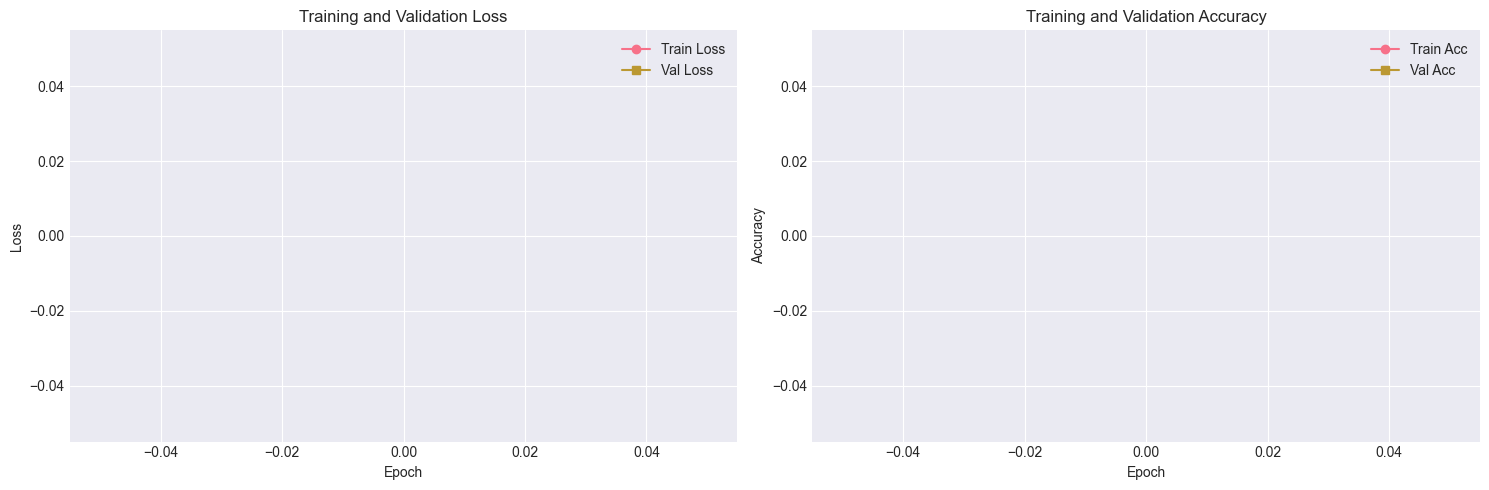


Evaluating Baseline CNN on Test Set:


Testing: 100%|██████████| 32/32 [00:06<00:00,  5.04it/s]


Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        40
         Low       0.00      0.00      0.00        61
      Medium       0.90      1.00      0.95       918

    accuracy                           0.90      1019
   macro avg       0.30      0.33      0.32      1019
weighted avg       0.81      0.90      0.85      1019



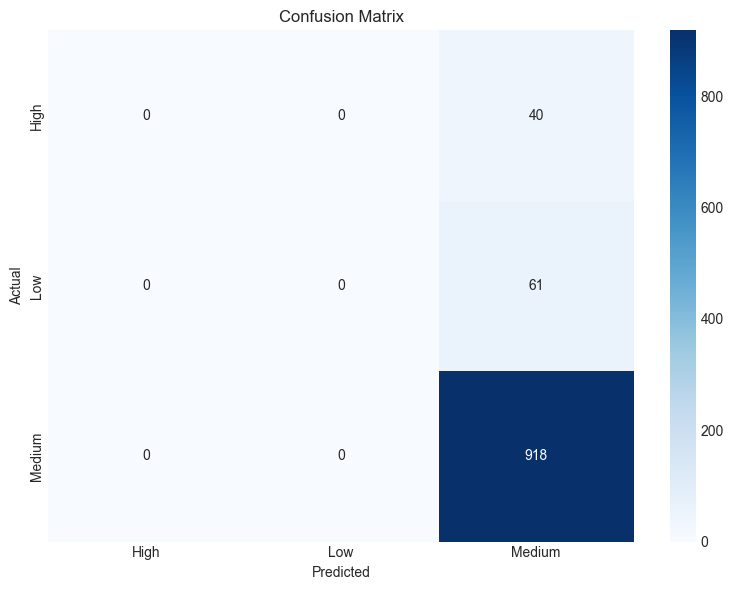

In [81]:
# Plot training history
plot_training_history(baseline_history)
plt.show()

# Evaluate on test set
print("\nEvaluating Baseline CNN on Test Set:")
print("=" * 80)
baseline_results = evaluate_model(baseline_model, test_loader, device,
                                 class_names=list(train_dataset.classes))

# Plot confusion matrix
plot_confusion_matrix(baseline_results['confusion_matrix'],
                     class_names=list(train_dataset.classes))
plt.show()


### 3.4 Model 2: ResNet18 (Transfer Learning)


In [82]:
# Initialize ResNet18 model
resnet_model = ResNetClassifier(num_classes=3, pretrained=True, model_name='resnet18').to(device)

# Count parameters
total_params = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)

print(f"ResNet18 Model:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Define loss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(resnet_model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Check if model checkpoint exists
resnet_checkpoint_path = 'models/resnet18_checkpoint.pth'
resnet_weights_path = 'models/resnet18_weights.pth'

if model_exists(resnet_checkpoint_path):
    print("\n" + "=" * 80)
    print("Loading existing ResNet18 checkpoint...")
    print("=" * 80)
    _, _, loaded_val_acc = load_model_checkpoint(resnet_model, optimizer, resnet_checkpoint_path, device)
    # Create a dummy history since we're loading a pre-trained model
    resnet_history = {
        'train_losses': [],
        'train_accs': [],
        'val_losses': [],
        'val_accs': [],
        'best_val_acc': loaded_val_acc if loaded_val_acc else 0.0
    }
    print("✓ ResNet18 model loaded. Skipping training.")
else:
    print("\nTraining ResNet18...")
    print("=" * 80)

    # Train model
    resnet_history = train_model(
        resnet_model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        device,
        num_epochs=15,
        early_stopping_patience=5,
        class_names=train_dataset.classes,
        checkpoint_path=resnet_checkpoint_path
    )

    # Also save weights-only version
    save_model_weights(resnet_model, resnet_weights_path)

    print(f"\nBest Validation Accuracy: {resnet_history['best_val_acc']:.4f}")


ResNet18 Model:
  Total parameters: 11,440,707
  Trainable parameters: 11,440,707

Loading existing ResNet18 checkpoint...
✓ Model checkpoint loaded from models/resnet18_checkpoint.pth
  Epoch: 3, Loss: 1.0917, Val Acc: 0.5113
✓ ResNet18 model loaded. Skipping training.


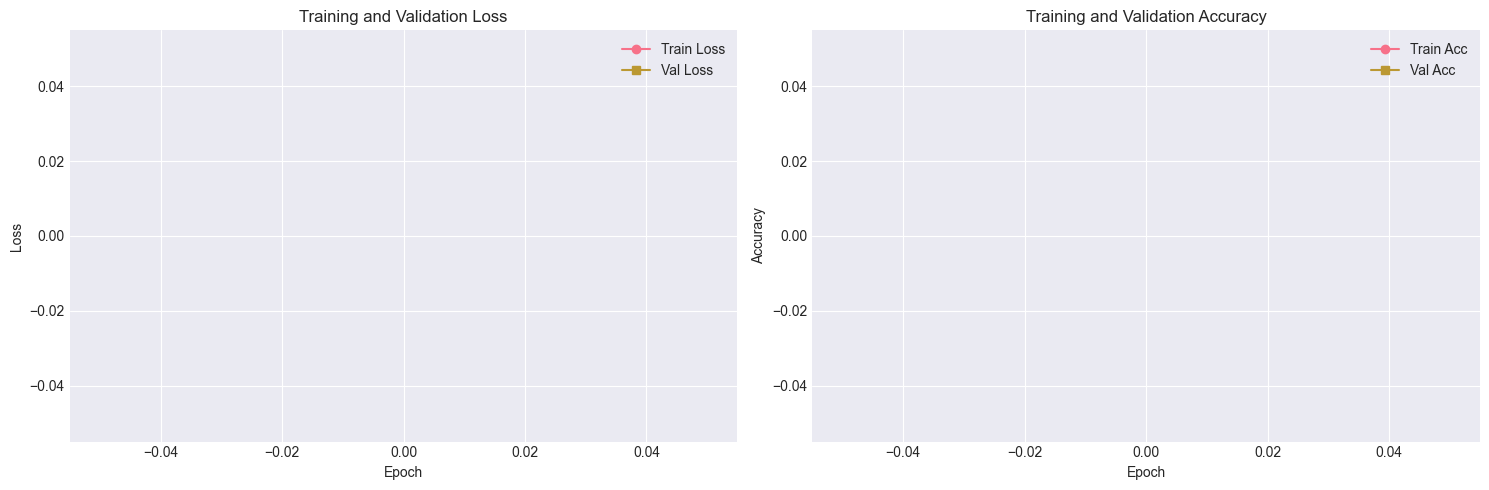


Evaluating ResNet18 on Test Set:


Testing: 100%|██████████| 32/32 [00:11<00:00,  2.81it/s]


Classification Report:
              precision    recall  f1-score   support

        High       0.04      0.33      0.08        40
         Low       0.08      0.34      0.13        61
      Medium       0.90      0.45      0.60       918

    accuracy                           0.44      1019
   macro avg       0.34      0.37      0.27      1019
weighted avg       0.82      0.44      0.55      1019



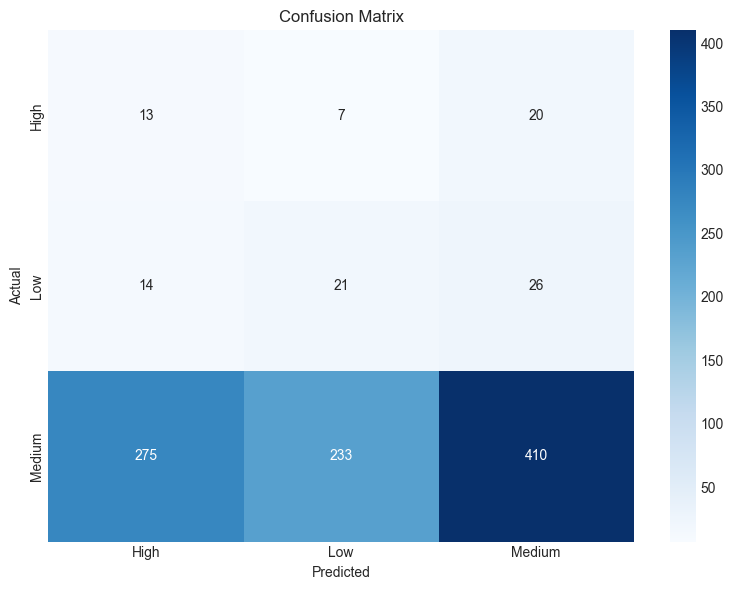

In [83]:
# Plot training history
plot_training_history(resnet_history)
plt.show()

# Evaluate on test set
print("\nEvaluating ResNet18 on Test Set:")
print("=" * 80)
resnet_results = evaluate_model(resnet_model, test_loader, device,
                                class_names=list(train_dataset.classes))

# Plot confusion matrix
plot_confusion_matrix(resnet_results['confusion_matrix'],
                     class_names=list(train_dataset.classes))
plt.show()


### 3.5 Model 3: EfficientNet-B0 (Transfer Learning)


In [84]:
# Initialize EfficientNet model
try:
    efficientnet_model = EfficientNetClassifier(num_classes=3, model_name='efficientnet_b0').to(device)

    # Count parameters
    total_params = sum(p.numel() for p in efficientnet_model.parameters())
    trainable_params = sum(p.numel() for p in efficientnet_model.parameters() if p.requires_grad)

    print(f"EfficientNet-B0 Model:")
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")

    # Define loss with class weights
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(efficientnet_model.parameters(), lr=0.0001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    # Check if model checkpoint exists
    efficientnet_checkpoint_path = 'models/efficientnet_b0_checkpoint.pth'
    efficientnet_weights_path = 'models/efficientnet_b0_weights.pth'

    if model_exists(efficientnet_checkpoint_path):
        print("\n" + "=" * 80)
        print("Loading existing EfficientNet-B0 checkpoint...")
        print("=" * 80)
        _, _, loaded_val_acc = load_model_checkpoint(efficientnet_model, optimizer, efficientnet_checkpoint_path, device)
        # Create a dummy history since we're loading a pre-trained model
        efficientnet_history = {
            'train_losses': [],
            'train_accs': [],
            'val_losses': [],
            'val_accs': [],
            'best_val_acc': loaded_val_acc if loaded_val_acc else 0.0
        }
        print("✓ EfficientNet-B0 model loaded. Skipping training.")
    else:
        print("\nTraining EfficientNet-B0...")
        print("=" * 80)

        # Train model
        efficientnet_history = train_model(
            efficientnet_model,
            train_loader,
            val_loader,
            criterion,
            optimizer,
            scheduler,
            device,
            num_epochs=15,
            early_stopping_patience=5,
            class_names=train_dataset.classes,
            checkpoint_path=efficientnet_checkpoint_path
        )

        # Also save weights-only version
        save_model_weights(efficientnet_model, efficientnet_weights_path)

        print(f"\nBest Validation Accuracy: {efficientnet_history['best_val_acc']:.4f}")

except ImportError as e:
    print(f"⚠️  EfficientNet not available: {e}")
    print("Skipping EfficientNet model. Install torchvision >= 0.13.0 to use it.")
    efficientnet_model = None
    efficientnet_history = None
    efficientnet_results = None


EfficientNet-B0 Model:
  Total parameters: 4,664,959
  Trainable parameters: 4,664,959

Loading existing EfficientNet-B0 checkpoint...
✓ Model checkpoint loaded from models/efficientnet_b0_checkpoint.pth
  Epoch: 3, Loss: 1.1225, Val Acc: 0.6654
✓ EfficientNet-B0 model loaded. Skipping training.


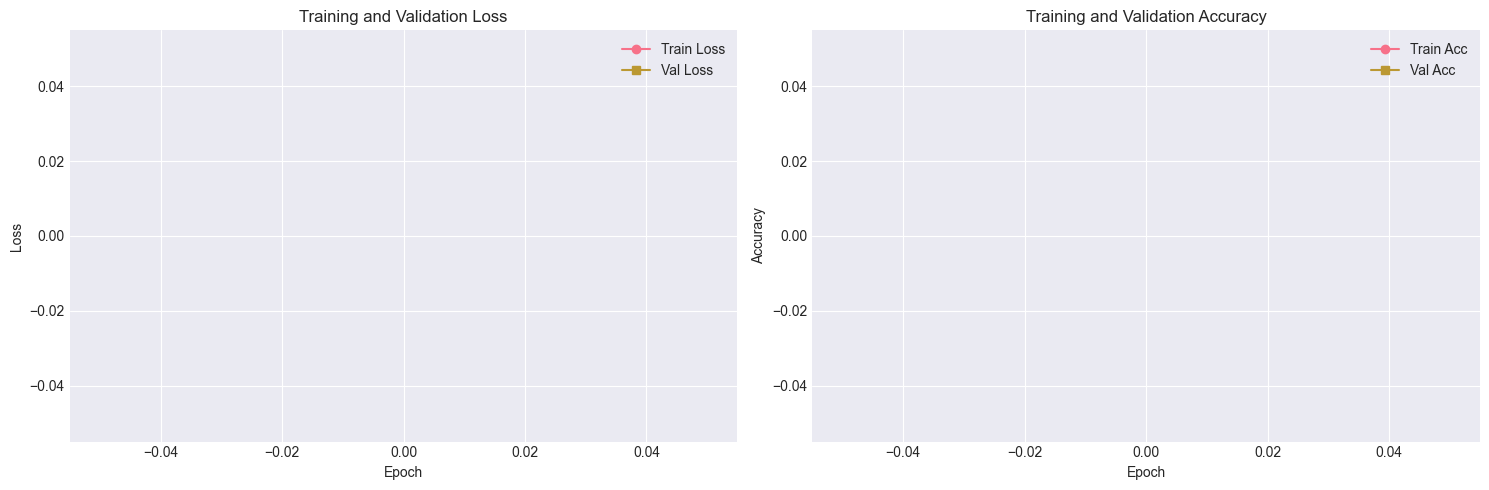


Evaluating EfficientNet-B0 on Test Set:


Testing: 100%|██████████| 32/32 [00:09<00:00,  3.30it/s]


Classification Report:
              precision    recall  f1-score   support

        High       0.05      0.28      0.08        40
         Low       0.08      0.54      0.13        61
      Medium       0.92      0.35      0.51       918

    accuracy                           0.36      1019
   macro avg       0.35      0.39      0.24      1019
weighted avg       0.83      0.36      0.47      1019



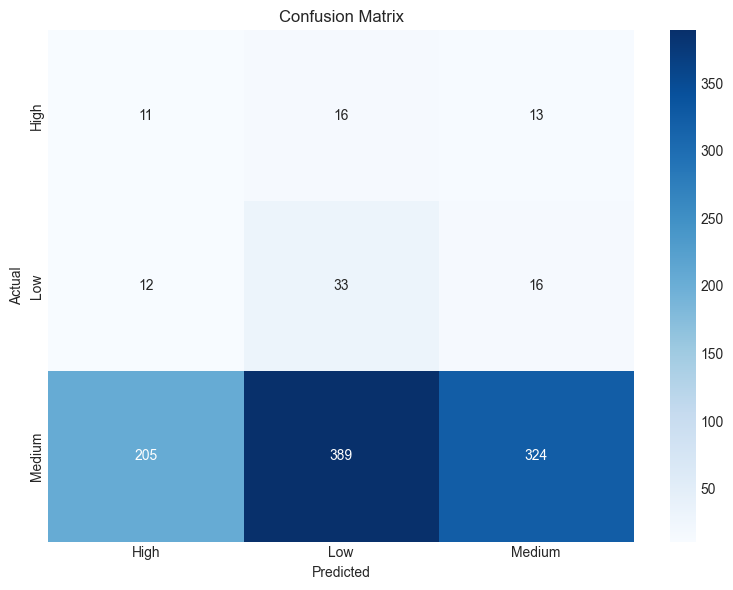

In [85]:
# Evaluate EfficientNet if available
if efficientnet_model is not None:
    # Plot training history
    plot_training_history(efficientnet_history)
    plt.show()

    # Evaluate on test set
    print("\nEvaluating EfficientNet-B0 on Test Set:")
    print("=" * 80)
    efficientnet_results = evaluate_model(efficientnet_model, test_loader, device,
                                          class_names=list(train_dataset.classes))

    # Plot confusion matrix
    plot_confusion_matrix(efficientnet_results['confusion_matrix'],
                         class_names=list(train_dataset.classes))
    plt.show()
else:
    efficientnet_results = None


### 3.6 Model 4: Custom CNN with Batch Normalization


In [86]:
# Initialize Custom CNN model
custom_model = CustomCNN(num_classes=3, input_size=IMAGE_SIZE).to(device)

# Count parameters
total_params = sum(p.numel() for p in custom_model.parameters())
trainable_params = sum(p.numel() for p in custom_model.parameters() if p.requires_grad)

print(f"Custom CNN Model:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Define loss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(custom_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Check if model checkpoint exists
custom_checkpoint_path = 'models/custom_cnn_checkpoint.pth'
custom_weights_path = 'models/custom_cnn_weights.pth'

if model_exists(custom_checkpoint_path):
    print("\n" + "=" * 80)
    print("Loading existing Custom CNN checkpoint...")
    print("=" * 80)
    _, _, loaded_val_acc = load_model_checkpoint(custom_model, optimizer, custom_checkpoint_path, device)
    # Create a dummy history since we're loading a pre-trained model
    custom_history = {
        'train_losses': [],
        'train_accs': [],
        'val_losses': [],
        'val_accs': [],
        'best_val_acc': loaded_val_acc if loaded_val_acc else 0.0
    }
    print("✓ Custom CNN model loaded. Skipping training.")
else:
    print("\nTraining Custom CNN...")
    print("=" * 80)

    # Train model
    custom_history = train_model(
        custom_model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        device,
        num_epochs=15,
        early_stopping_patience=5,
        class_names=train_dataset.classes,
        checkpoint_path=custom_checkpoint_path
    )

    # Also save weights-only version
    save_model_weights(custom_model, custom_weights_path)

    print(f"\nBest Validation Accuracy: {custom_history['best_val_acc']:.4f}")


Custom CNN Model:
  Total parameters: 107,977,027
  Trainable parameters: 107,977,027

Loading existing Custom CNN checkpoint...
✓ Model checkpoint loaded from models/custom_cnn_checkpoint.pth
  Epoch: 2, Loss: 1.0911, Val Acc: 0.9009
✓ Custom CNN model loaded. Skipping training.


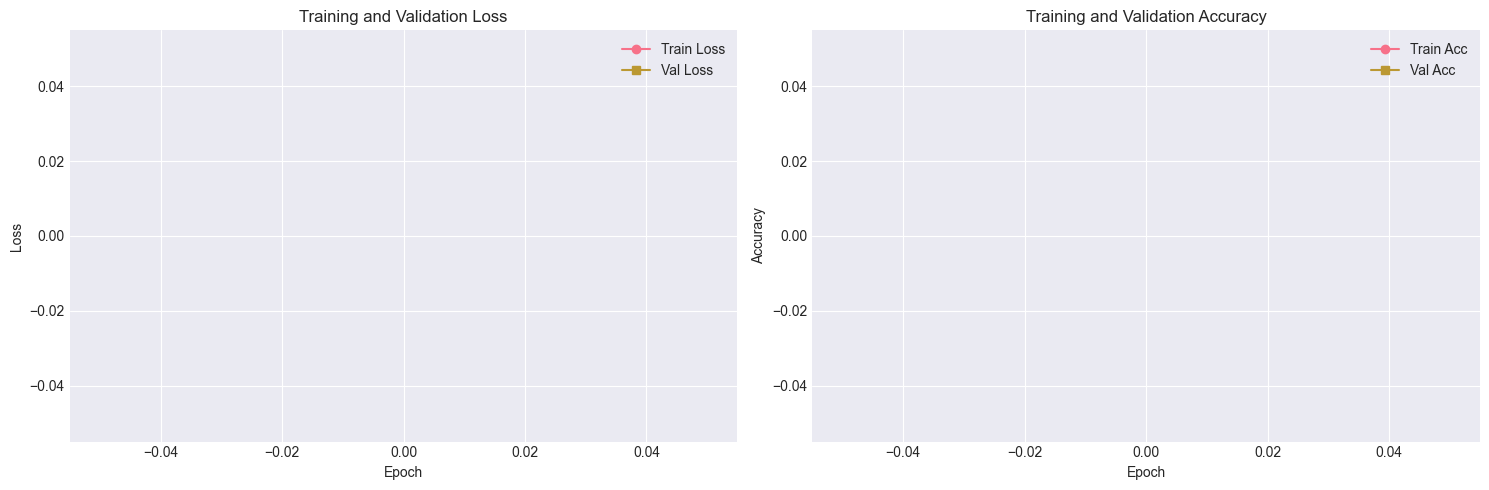


Evaluating Custom CNN on Test Set:


Testing: 100%|██████████| 32/32 [00:39<00:00,  1.25s/it]


Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        40
         Low       0.00      0.00      0.00        61
      Medium       0.90      1.00      0.95       918

    accuracy                           0.90      1019
   macro avg       0.30      0.33      0.32      1019
weighted avg       0.81      0.90      0.85      1019



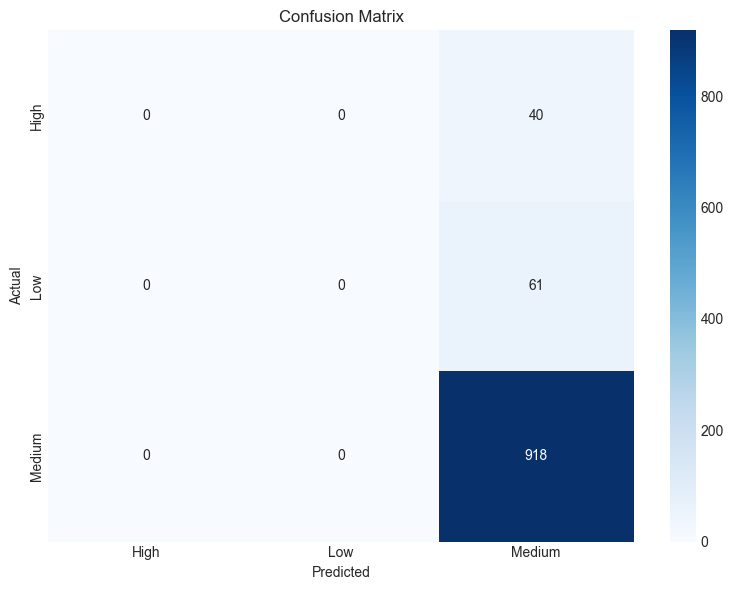

In [87]:
# Plot training history
plot_training_history(custom_history)
plt.show()

# Evaluate on test set
print("\nEvaluating Custom CNN on Test Set:")
print("=" * 80)
custom_results = evaluate_model(custom_model, test_loader, device,
                                class_names=list(train_dataset.classes))

# Plot confusion matrix
plot_confusion_matrix(custom_results['confusion_matrix'],
                     class_names=list(train_dataset.classes))
plt.show()


## 4. Evaluation Criteria

We evaluate our models using the following metrics:

1. **Accuracy** - Overall classification accuracy
2. **Precision** - Per-class precision (Low, Medium, High risk)
3. **Recall** - Per-class recall
4. **F1-Score** - Harmonic mean of precision and recall
5. **Macro-Averaged Metrics** - Average across all classes (important for imbalanced data)
6. **Confusion Matrix** - Visual representation of classification performance

### Risk Level Definitions:
- **Low Risk**: Minimal poaching activity expected
- **Medium Risk**: Moderate poaching activity expected
- **High Risk**: High poaching activity expected

### Handling Class Imbalance:
- We use **weighted loss functions** to give more importance to minority classes (Low and High risk)
- Class weights are calculated based on inverse frequency


## 5. Results and Model Comparison


In [88]:
# Compile results from all models
results_summary = {
    'Model': ['Baseline CNN', 'ResNet18', 'Custom CNN'],
    'Test Accuracy': [
        baseline_results['accuracy'],
        resnet_results['accuracy'],
        custom_results['accuracy']
    ],
    'Precision (Macro)': [
        baseline_results['precision_macro'],
        resnet_results['precision_macro'],
        custom_results['precision_macro']
    ],
    'Recall (Macro)': [
        baseline_results['recall_macro'],
        resnet_results['recall_macro'],
        custom_results['recall_macro']
    ],
    'F1-Score (Macro)': [
        baseline_results['f1_macro'],
        resnet_results['f1_macro'],
        custom_results['f1_macro']
    ],
    'Best Val Accuracy': [
        baseline_history['best_val_acc'],
        resnet_history['best_val_acc'],
        custom_history['best_val_acc']
    ]
}

# Add EfficientNet if available
if efficientnet_results is not None:
    results_summary['Model'].append('EfficientNet-B0')
    results_summary['Test Accuracy'].append(efficientnet_results['accuracy'])
    results_summary['Precision (Macro)'].append(efficientnet_results['precision_macro'])
    results_summary['Recall (Macro)'].append(efficientnet_results['recall_macro'])
    results_summary['F1-Score (Macro)'].append(efficientnet_results['f1_macro'])
    results_summary['Best Val Accuracy'].append(efficientnet_history['best_val_acc'])

results_df = pd.DataFrame(results_summary)
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False))


MODEL COMPARISON SUMMARY
          Model  Test Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  Best Val Accuracy
   Baseline CNN       0.900883           0.300294        0.333333          0.315953           0.900883
       ResNet18       0.435721           0.340876        0.371962          0.267752           0.511286
     Custom CNN       0.900883           0.300294        0.333333          0.315953           0.900883
EfficientNet-B0       0.361138           0.347145        0.389642          0.241396           0.665358


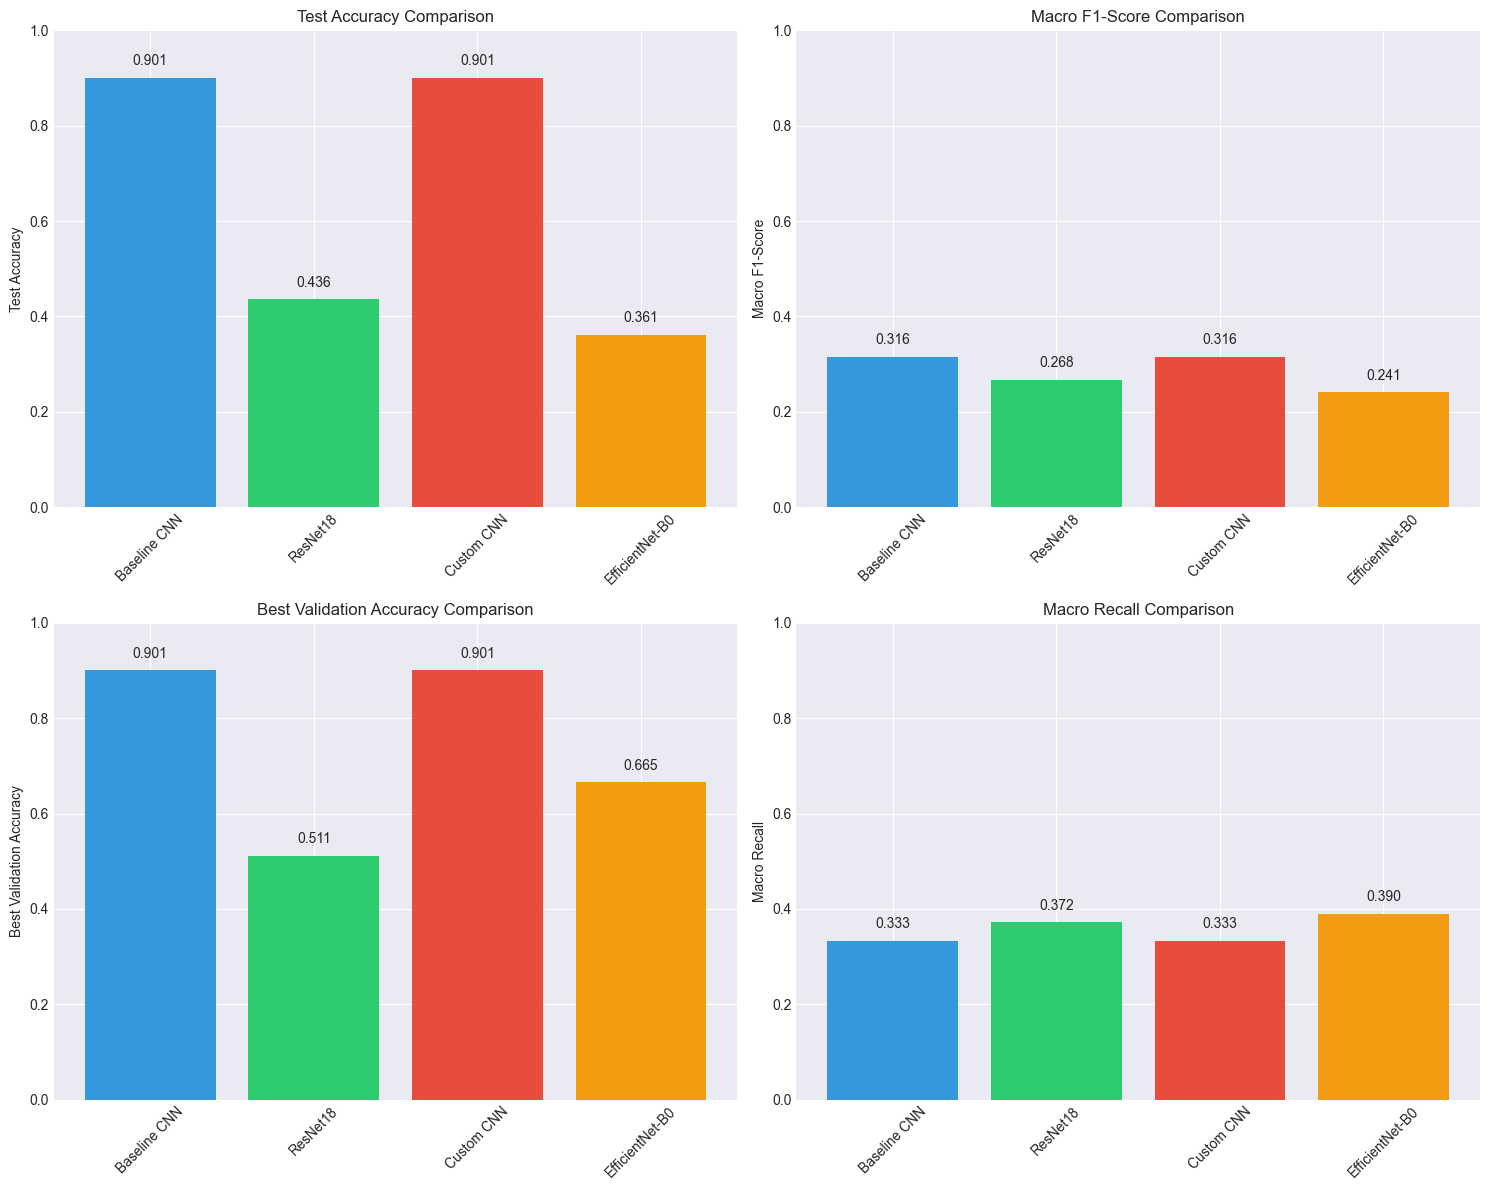

In [89]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Test Accuracy comparison
axes[0, 0].bar(results_df['Model'], results_df['Test Accuracy'],
               color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'][:len(results_df)])
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['Test Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# Macro F1-Score comparison
axes[0, 1].bar(results_df['Model'], results_df['F1-Score (Macro)'],
               color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'][:len(results_df)])
axes[0, 1].set_ylabel('Macro F1-Score')
axes[0, 1].set_title('Macro F1-Score Comparison')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['F1-Score (Macro)']):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# Validation accuracy comparison
axes[1, 0].bar(results_df['Model'], results_df['Best Val Accuracy'],
               color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'][:len(results_df)])
axes[1, 0].set_ylabel('Best Validation Accuracy')
axes[1, 0].set_title('Best Validation Accuracy Comparison')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['Best Val Accuracy']):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# Macro Recall comparison
axes[1, 1].bar(results_df['Model'], results_df['Recall (Macro)'],
              color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'][:len(results_df)])
axes[1, 1].set_ylabel('Macro Recall')
axes[1, 1].set_title('Macro Recall Comparison')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['Recall (Macro)']):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [90]:
# Detailed per-class metrics comparison
class_metrics = {
    'Model': ['Baseline CNN', 'ResNet18', 'Custom CNN'],
    'Low Risk - Precision': [
        baseline_results['precision'][0],
        resnet_results['precision'][0],
        custom_results['precision'][0]
    ],
    'Low Risk - Recall': [
        baseline_results['recall'][0],
        resnet_results['recall'][0],
        custom_results['recall'][0]
    ],
    'Medium Risk - Precision': [
        baseline_results['precision'][1],
        resnet_results['precision'][1],
        custom_results['precision'][1]
    ],
    'Medium Risk - Recall': [
        baseline_results['recall'][1],
        resnet_results['recall'][1],
        custom_results['recall'][1]
    ],
    'High Risk - Precision': [
        baseline_results['precision'][2],
        resnet_results['precision'][2],
        custom_results['precision'][2]
    ],
    'High Risk - Recall': [
        baseline_results['recall'][2],
        resnet_results['recall'][2],
        custom_results['recall'][2]
    ]
}

# Add EfficientNet if available
if efficientnet_results is not None:
    class_metrics['Model'].append('EfficientNet-B0')
    class_metrics['Low Risk - Precision'].append(efficientnet_results['precision'][0])
    class_metrics['Low Risk - Recall'].append(efficientnet_results['recall'][0])
    class_metrics['Medium Risk - Precision'].append(efficientnet_results['precision'][1])
    class_metrics['Medium Risk - Recall'].append(efficientnet_results['recall'][1])
    class_metrics['High Risk - Precision'].append(efficientnet_results['precision'][2])
    class_metrics['High Risk - Recall'].append(efficientnet_results['recall'][2])

class_metrics_df = pd.DataFrame(class_metrics)
print("\n" + "=" * 80)
print("PER-CLASS METRICS COMPARISON")
print("=" * 80)
print(class_metrics_df.to_string(index=False))



PER-CLASS METRICS COMPARISON
          Model  Low Risk - Precision  Low Risk - Recall  Medium Risk - Precision  Medium Risk - Recall  High Risk - Precision  High Risk - Recall
   Baseline CNN              0.000000              0.000                 0.000000              0.000000               0.900883            1.000000
       ResNet18              0.043046              0.325                 0.080460              0.344262               0.899123            0.446623
     Custom CNN              0.000000              0.000                 0.000000              0.000000               0.900883            1.000000
EfficientNet-B0              0.048246              0.275                 0.075342              0.540984               0.917847            0.352941
